<a href="https://colab.research.google.com/github/Phuc1Le/pyTorch-from-scratch/blob/main/CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
transform = transforms.ToTensor()


In [3]:
train_data = datasets.MNIST(root = "cnn_data", train = True, download = True, transform = transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 117MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 26.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 89.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


In [4]:
train_loader = DataLoader(train_data, batch_size = 10, shuffle = True)

In [5]:
test_data = datasets.MNIST(root = "cnn_data", train = False, download = True, transform = transform)
test_loader = DataLoader(test_data, batch_size = 10, shuffle = False)

In [6]:
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)


In [7]:
for i, (X_train, y_train) in enumerate(train_data):
  break

In [8]:
x = X_train.view(1,1,28,28)
x = F.relu(conv1(x))

In [9]:
x.shape

torch.Size([1, 6, 26, 26])

In [10]:
x = F.max_pool2d(x,2,2)

In [11]:
x = F.relu(conv2(x))
x.shape

torch.Size([1, 16, 11, 11])

In [12]:
x = F.max_pool2d(x,2,2)

In [13]:
x.shape

torch.Size([1, 16, 5, 5])

In [14]:
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1,6,3,1)
    self.conv2 = nn.Conv2d(6,16,3,1)
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120,84)
    self.fc3 = nn.Linear(84,10)
  def forward(self,X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X,2,2)
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X,2,2)
    X = X.view(-1,5*5*16)
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)
    return F.log_softmax(X, dim = 1)


In [15]:
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)


In [17]:
import time

In [27]:
start_time = time.time()

epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  for b, (X_train, y_train) in enumerate(train_loader):
    b += 1
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    predicted = torch.max(y_pred.data, 1)[1]
    batch_corr = (predicted == y_train).sum()
    trn_corr += batch_corr
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if b%600==0:
      print(f'Epoch {i} Batch {b} Loss {loss.item()}')
  train_losses.append(loss)
  train_correct.append(trn_corr)

  with torch.no_grad():
    for b, (X_test, y_test) in enumerate(test_loader):
      b += 1
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1]
      tst_corr += (predicted == y_test).sum()
  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)


current_time = time.time()
total_time = current_time - start_time
print(f'Training took {total_time/60} minutes')

Epoch 0 Batch 600 Loss 4.6734676288906485e-05
Epoch 0 Batch 1200 Loss 0.011104440316557884
Epoch 0 Batch 1800 Loss 9.620944183552638e-05
Epoch 0 Batch 2400 Loss 0.011589272879064083
Epoch 0 Batch 3000 Loss 0.015681806951761246
Epoch 0 Batch 3600 Loss 0.00032461804221384227
Epoch 0 Batch 4200 Loss 6.992203270783648e-05
Epoch 0 Batch 4800 Loss 1.9024966604774818e-05
Epoch 0 Batch 5400 Loss 0.07457058131694794
Epoch 0 Batch 6000 Loss 0.0004053508455399424
Epoch 1 Batch 600 Loss 1.8929047655547038e-05
Epoch 1 Batch 1200 Loss 0.0001132140023401007
Epoch 1 Batch 1800 Loss 7.237242243718356e-05
Epoch 1 Batch 2400 Loss 0.0001621227420400828
Epoch 1 Batch 3000 Loss 6.36039549135603e-05
Epoch 1 Batch 3600 Loss 0.021514009684324265
Epoch 1 Batch 4200 Loss 0.00026443079696036875
Epoch 1 Batch 4800 Loss 3.48402900272049e-05
Epoch 1 Batch 5400 Loss 0.3259724974632263
Epoch 1 Batch 6000 Loss 0.9794745445251465
Epoch 2 Batch 600 Loss 4.518773130257614e-05
Epoch 2 Batch 1200 Loss 1.3207698430051096e-05

In [28]:
train_losses = [tl.item() for tl in train_losses]
test_losses = [tl.item() for tl in test_losses]

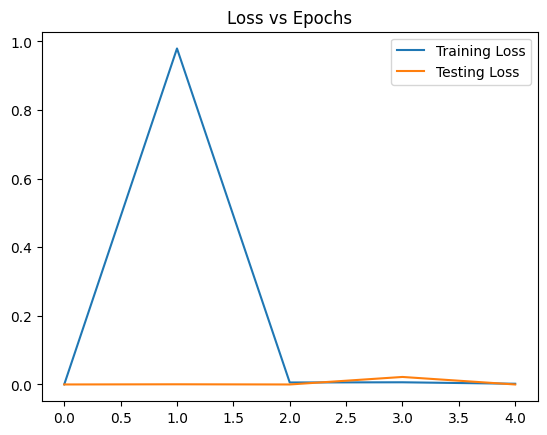

In [29]:
plt.plot(train_losses, label = "Training Loss")
plt.plot(test_losses, label = "Testing Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

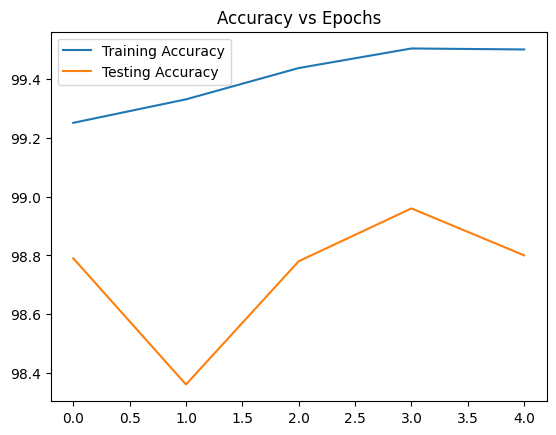

In [31]:
plt.plot([t/600 for t in train_correct], label = "Training Accuracy")
plt.plot([t/100 for t in test_correct], label = "Testing Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.show()

In [32]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle = False)
final_correct = 0
with torch.no_grad():
  for X_test, y_test in test_load_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val.data, 1)[1]
    final_correct += (predicted == y_test).sum()

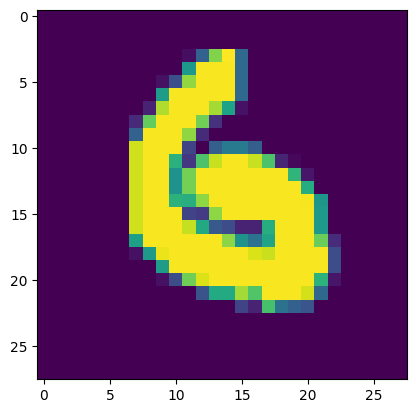

In [36]:
plt.imshow(test_data[903][0].reshape(28,28))

In [37]:
model.eval()
with torch.no_grad():
  new_pred = model(test_data[903][0].view(1,1,28,28))
new_pred.argmax()

tensor(6)